# Vector store benchmark

**for non-sqlite store: engine = implementation folder × compile-flag set × label.** The implementation
is picked at compile time via `-I<impls_dir>/<keyword>`, so one `bench_cpp.cpp`
benchmarks any `impls/<keyword>/vector_store.h` against any flags — no Makefile.

Knobs, all in the CONFIG cell below:
* **`ENGINES`** — map each engine label to its implementation + flags + colour.
* **`SELECTED`** — which engines get built and plotted.
* **`METRIC`** — distance type for the whole run: `"euclidean"` or `"cosine"`.

Two plots:
* **Latency vs N** (log–log line, one line per engine, one figure per dim) — driven by `SELECTED`.
* **Normalized speedup** (grouped bars, one figure per dim) — driven by `SPEEDUP`, a list of exactly 3 engine labels `[baseline, engine2, engine3]`; each N shows two bars (engine2 and engine3 speedup vs the baseline, which sits at 1.0×).

> Any selected engine whose folder does not exist yet is skipped with a note

In [16]:
# ============================ CONFIG ============================
from pathlib import Path
import importlib
import bench
importlib.reload(bench)   # pick up edits to bench.py without restarting the kernel
from bench import Engine

# Where implementation folders live (each holds a vector_store.h).
bench.IMPLS_DIR = Path("../impls")

DIMS = [128, 384, 768]        # one figure per dim
NS   = [1000, 10000, 100000]  # x-axis (number of stored vectors)
K    = 10                     # neighbours per query
# METRIC = "euclidean"          # distance type: "euclidean" or "cosine"
METRIC = "cosine"

# The full registry: label -> (implementation folder, compile flags, colour).
# `flags` is a raw g++ string. Common presets: "", "-O2", "-O3", "-O3 -ffast-math"
# The same impl at different flags is simply two different engines.
ENGINES = {
    "initial_design_no_opt":              Engine(impl="initial_design_no_opt",    flags="",                             color="tab:blue"),
    "optimized_O3":          Engine(impl="optimized_no_manual_simd",   flags="-O3",                          color="tab:green"),
    "optimized_O3_ffast_math":   Engine(impl="optimized_no_manual_simd",   flags="-O3 -ffast-math",             color="tab:orange"),
    "optimized_with_manual_simd_O3":    Engine(impl="optimized_with_manual_simd",   flags="-O3", color="tab:brown"),
    "sqlite_vec":          Engine(kind="sqlite",    flags="-O3",                          color="tab:purple"),
}


[ok]   optimized_O3
[ok]   optimized_O3_ffast_math
[ok]   sqlite_vec
[sum]  optimized_O3 n=1000 dim=128: checksum=50770
[sum]  optimized_O3 n=10000 dim=128: checksum=474502
[sum]  optimized_O3 n=100000 dim=128: checksum=5298295
[run]  optimized_O3 dim=128: 1000:0.1456ms, 10000:0.5517ms, 100000:5.454ms
[sum]  optimized_O3_ffast_math n=1000 dim=128: checksum=50770
[sum]  optimized_O3_ffast_math n=10000 dim=128: checksum=474502
[sum]  optimized_O3_ffast_math n=100000 dim=128: checksum=5298295
[run]  optimized_O3_ffast_math dim=128: 1000:0.02564ms, 10000:0.101ms, 100000:1.089ms
[sum]  sqlite_vec n=1000 dim=128: checksum=50770
[sum]  sqlite_vec n=10000 dim=128: checksum=474502
[sum]  sqlite_vec n=100000 dim=128: checksum=5298295
[run]  sqlite_vec dim=128: 1000:0.1333ms, 10000:1.121ms, 100000:11.17ms
[sum]  optimized_O3 n=1000 dim=384: checksum=46126
[sum]  optimized_O3 n=10000 dim=384: checksum=553837
[sum]  optimized_O3 n=100000 dim=384: checksum=5346138
[run]  optimized_O3 dim=384: 1000:0

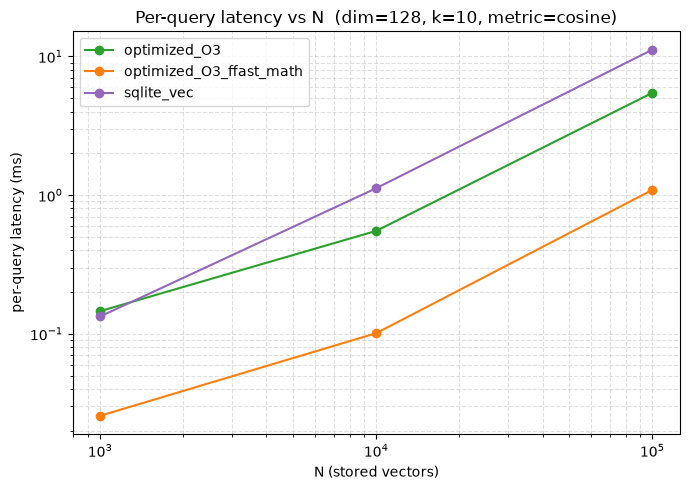

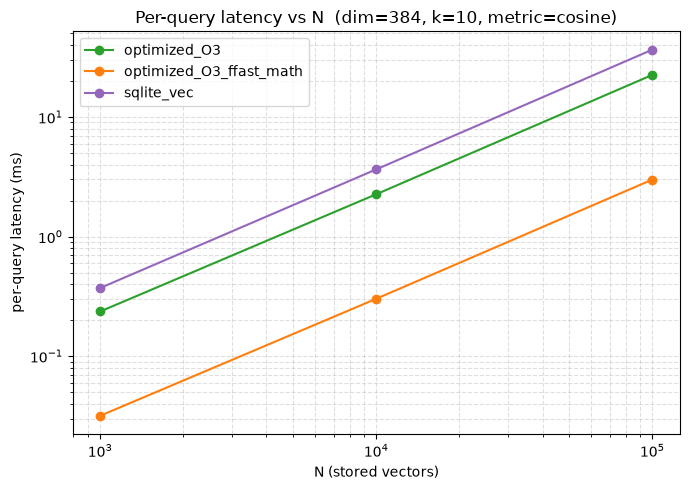

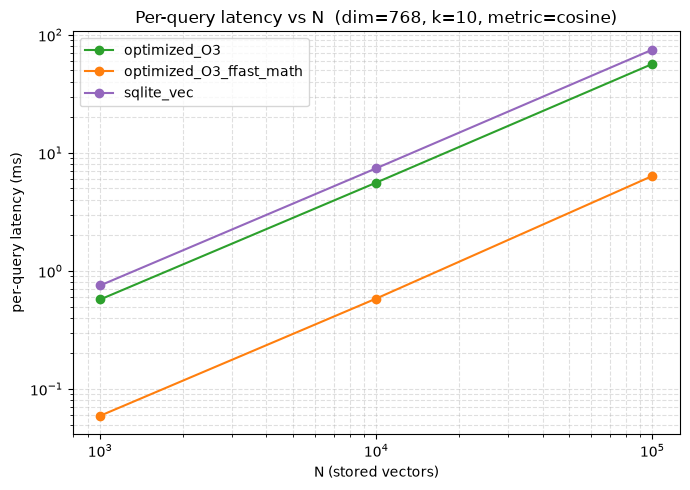

In [17]:
# Build the selected engines and plot latency vs N (one figure per dim).
# Missing impls / unavailable sqlite are skipped with a note.
%matplotlib inline
SELECTED = ["optimized_O3","optimized_O3_ffast_math","sqlite_vec"]
bench.benchmark(ENGINES, SELECTED, NS, DIMS, K, METRIC)

[ok]   initial_design_no_opt
[ok]   optimized_O3
[ok]   optimized_O3_ffast_math
[sum]  initial_design_no_opt n=1000 dim=128: checksum=50770
[sum]  initial_design_no_opt n=10000 dim=128: checksum=474502
[sum]  initial_design_no_opt n=100000 dim=128: checksum=5298295
[sum]  optimized_O3 n=1000 dim=128: checksum=50770
[sum]  optimized_O3 n=10000 dim=128: checksum=474502
[sum]  optimized_O3 n=100000 dim=128: checksum=5298295
[sum]  optimized_O3_ffast_math n=1000 dim=128: checksum=50770
[sum]  optimized_O3_ffast_math n=10000 dim=128: checksum=474502
[sum]  optimized_O3_ffast_math n=100000 dim=128: checksum=5298295
[spd]  dim=128 optimized_O3 vs initial_design_no_opt: 1000:33.19x, 10000:53.04x, 100000:55.10x
[spd]  dim=128 optimized_O3_ffast_math vs initial_design_no_opt: 1000:112.93x, 10000:269.41x, 100000:287.67x
[sum]  initial_design_no_opt n=1000 dim=384: checksum=46126
[sum]  initial_design_no_opt n=10000 dim=384: checksum=553837
[sum]  initial_design_no_opt n=100000 dim=384: checksum=5

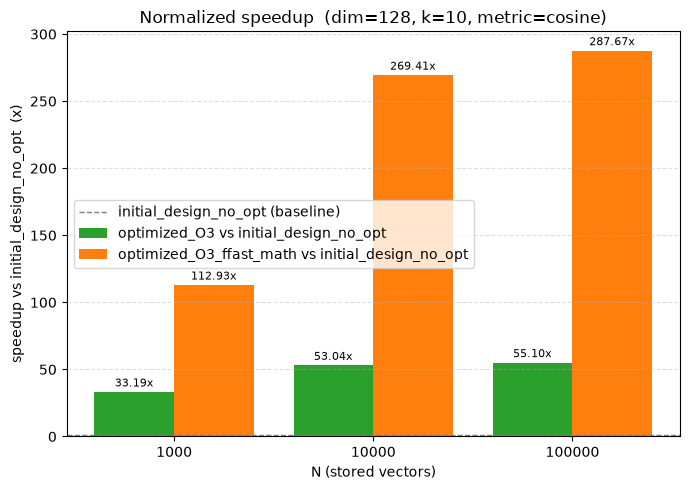

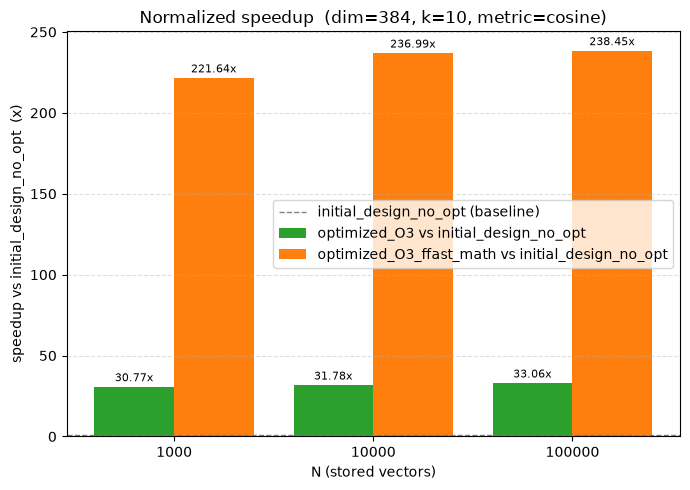

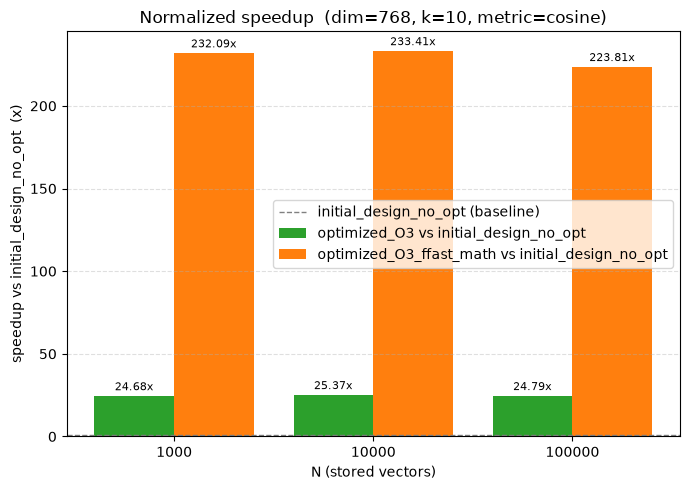

In [18]:
# Normalized speedup bar chart. Exactly 3 engines: [baseline, engine2, engine3].
# Per N, two bars: engine2 vs baseline and engine3 vs baseline (baseline = 1.0x,
# >1 = faster). One figure per dim.
%matplotlib inline
SPEEDUP = ["initial_design_no_opt", "optimized_O3","optimized_O3_ffast_math"]  # [baseline, e2, e3]
bench.speedup_chart(ENGINES, SPEEDUP, NS, DIMS, K, METRIC)